In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from unidecode import unidecode


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\kevin\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\kevin\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\kevin\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_lo

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\kevin\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\kevin\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\kevin\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_lo

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [24]:
df=pd.read_csv('ChocoCrunchAnalytics.csv',encoding='utf_8')
df.head(5)

,Unnamed: 0,brands,code,product_name,energy-kcal_value,energy-kj_value,carbohydrates_value,sugars_value,fat_value,saturated-fat_value,proteins_value,fiber_value,salt_value,sodium_value,nova-group,nutrition-score-fr,fruits-vegetables-nuts-estimate-from-ingredients_100g
0,0,Sidi Ali,6111035000430,Sidi Ali,0.0,20.0,42.0,14.0,0.0,0.0,0.0,0.0,0.00000,0.000000,NaN,1.0,0.0
1,1,Jaouda,6111242100992,Perly,97.0,406.0,9.4,NaN,3.0,NaN,8.0,NaN,NaN,NaN,3.0,NaN,0.0
2,2,sidi ali,6111035002175,Sidi Ali,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.00000,26.000000,NaN,0.0,0.0
3,3,"Les Eaux Minérales d'oulmès,Sidi Ali",6111035000058,Eau minérale naturelle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.00000,26.000000,1.0,0.0,0.0
4,4,AQUAFINA,6111252421568,اكوافينا,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00508,0.002032,NaN,0.0,0.0


In [25]:
#removing first column
df=df.iloc[:,1:]
df.head(5)

,brands,code,product_name,energy-kcal_value,energy-kj_value,carbohydrates_value,sugars_value,fat_value,saturated-fat_value,proteins_value,fiber_value,salt_value,sodium_value,nova-group,nutrition-score-fr,fruits-vegetables-nuts-estimate-from-ingredients_100g
0,Sidi Ali,6111035000430,Sidi Ali,0.0,20.0,42.0,14.0,0.0,0.0,0.0,0.0,0.00000,0.000000,NaN,1.0,0.0
1,Jaouda,6111242100992,Perly,97.0,406.0,9.4,NaN,3.0,NaN,8.0,NaN,NaN,NaN,3.0,NaN,0.0
2,sidi ali,6111035002175,Sidi Ali,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.00000,26.000000,NaN,0.0,0.0
3,"Les Eaux Minérales d'oulmès,Sidi Ali",6111035000058,Eau minérale naturelle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.00000,26.000000,1.0,0.0,0.0
4,AQUAFINA,6111252421568,اكوافينا,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00508,0.002032,NaN,0.0,0.0


In [26]:
df.duplicated().sum()
#No duplicated values

np.int64(0)

In [27]:
df.shape

(11997, 16)

In [28]:
df.isnull().sum()

brands                                                    652
code                                                        0
product_name                                              546
energy-kcal_value                                         764
energy-kj_value                                          5571
carbohydrates_value                                       765
sugars_value                                              979
fat_value                                                 737
saturated-fat_value                                      1049
proteins_value                                            747
fiber_value                                              3822
salt_value                                               1076
sodium_value                                             1076
nova-group                                               1267
nutrition-score-fr                                       1685
fruits-vegetables-nuts-estimate-from-ingredients_100g     725
dtype: i

In [29]:
fribrenull=(3822/11997)*100
print(f'fiber_value column has {fribrenull:.2f}% null vaues')


fiber_value column has 31.86% null vaues


In [30]:
#removing fiber_value column
df=df.drop('fiber_value',axis=1)

- energy-kj_value has 5571 null values but values could be found using energy-kcal_value column

In [31]:
#dropping null values in brands and product_name
df = df.dropna(subset=["brands"])
df.shape

(11345, 15)

In [32]:
df.isnull().sum()

brands                                                      0
code                                                        0
product_name                                              298
energy-kcal_value                                         419
energy-kj_value                                          4992
carbohydrates_value                                       410
sugars_value                                              621
fat_value                                                 391
saturated-fat_value                                       694
proteins_value                                            400
salt_value                                                701
sodium_value                                              701
nova-group                                                852
nutrition-score-fr                                       1264
fruits-vegetables-nuts-estimate-from-ingredients_100g     345
dtype: int64

In [33]:
datalost=100-((11345/11997)*100)
print(f'{datalost:.2f}% of data lost after removing the missing values in brands')

5.43% of data lost after removing the missing values in brands


In [34]:
df.describe()

,code,energy-kcal_value,energy-kj_value,carbohydrates_value,sugars_value,fat_value,saturated-fat_value,proteins_value,salt_value,sodium_value,nova-group,nutrition-score-fr,fruits-vegetables-nuts-estimate-from-ingredients_100g
count,1.134500e+04,10926.000000,6353.000000,10935.000000,10724.000000,10954.000000,10651.000000,10945.000000,10644.000000,10644.000000,10493.000000,10081.000000,11000.000000
mean,4.461099e+12,279.012146,1224.746703,29.461214,11.407627,14.726096,5.106703,7.306042,18.201917,7.280767,3.301058,8.935125,18.332220
std,2.405407e+12,483.587989,848.521348,95.276345,19.368134,38.108108,11.164151,30.026098,846.317584,338.527034,1.010899,9.758887,30.709887
min,1.816600e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-15.000000,-0.066406
25%,3.229820e+12,91.000000,423.000000,4.600000,1.000000,1.200000,0.300000,1.400000,0.050000,0.020000,3.000000,1.000000,0.000000
50%,4.058172e+12,241.000000,1196.000000,15.120000,4.100000,6.200000,1.400000,5.700000,0.380000,0.152000,4.000000,7.000000,0.270417
75%,6.111028e+12,432.000000,1877.000000,55.000000,13.000000,21.000000,5.900000,9.400000,1.000000,0.400000,4.000000,16.000000,22.222222
max,9.780201e+12,45793.499044,3768.000000,8989.000000,895.000000,3400.000000,595.000000,3000.000000,85000.000000,34000.000000,4.000000,50.000000,197.200000


In [35]:
df.head(5)

,brands,code,product_name,energy-kcal_value,energy-kj_value,carbohydrates_value,sugars_value,fat_value,saturated-fat_value,proteins_value,salt_value,sodium_value,nova-group,nutrition-score-fr,fruits-vegetables-nuts-estimate-from-ingredients_100g
0,Sidi Ali,6111035000430,Sidi Ali,0.0,20.0,42.0,14.0,0.0,0.0,0.0,0.00000,0.000000,NaN,1.0,0.0
1,Jaouda,6111242100992,Perly,97.0,406.0,9.4,NaN,3.0,NaN,8.0,NaN,NaN,3.0,NaN,0.0
2,sidi ali,6111035002175,Sidi Ali,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.00000,26.000000,NaN,0.0,0.0
3,"Les Eaux Minérales d'oulmès,Sidi Ali",6111035000058,Eau minérale naturelle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.00000,26.000000,1.0,0.0,0.0
4,AQUAFINA,6111252421568,اكوافينا,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00508,0.002032,NaN,0.0,0.0


In [36]:
df['product_name']=df['product_name'].astype(str).apply(unidecode)
df['brands']=df['brands'].apply(unidecode)

df

,brands,code,product_name,energy-kcal_value,energy-kj_value,carbohydrates_value,sugars_value,fat_value,saturated-fat_value,proteins_value,salt_value,sodium_value,nova-group,nutrition-score-fr,fruits-vegetables-nuts-estimate-from-ingredients_100g
0,Sidi Ali,6111035000430,Sidi Ali,0.0,20.0,42.0,14.0,0.0,0.0,0.0,0.00000,0.000000,NaN,1.0,0.000000
1,Jaouda,6111242100992,Perly,97.0,406.0,9.4,NaN,3.0,NaN,8.0,NaN,NaN,3.0,NaN,0.000000
2,sidi ali,6111035002175,Sidi Ali,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.00000,26.000000,NaN,0.0,0.000000
3,"Les Eaux Minerales d'oulmes,Sidi Ali",6111035000058,Eau minerale naturelle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.00000,26.000000,1.0,0.0,0.000000
4,AQUAFINA,6111252421568,kwfyn,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00508,0.002032,NaN,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11990,MCENNEDY,4056489774747,nan,355.0,NaN,87.6,82.3,0.0,0.0,1.2,0.01000,0.004000,2.0,19.0,0.000000
11991,Sultan,6111069000819,The vert en grain najma,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.00000,0.000000,NaN,NaN,NaN
11992,Nairn's,612322001612,nairns dark chocolate chip oat biscuits,454.0,1902.0,63.8,19.0,16.9,7.7,8.1,0.78000,0.312000,4.0,16.0,0.000000
11993,Swizzels,5010478014510,Drumstick Squashies,356.0,NaN,84.0,63.0,0.2,0.0,3.4,0.07000,0.028000,4.0,19.0,0.351562


In [37]:
df['brands']=df['brands'].str.replace(r'[^A-Za-z0-9\s]', '', regex=True)
df['product_name']=df['product_name'].str.replace(r'[^A-Za-z0-9\s]', '', regex=True)
df.head()


,brands,code,product_name,energy-kcal_value,energy-kj_value,carbohydrates_value,sugars_value,fat_value,saturated-fat_value,proteins_value,salt_value,sodium_value,nova-group,nutrition-score-fr,fruits-vegetables-nuts-estimate-from-ingredients_100g
0,Sidi Ali,6111035000430,Sidi Ali,0.0,20.0,42.0,14.0,0.0,0.0,0.0,0.00000,0.000000,NaN,1.0,0.0
1,Jaouda,6111242100992,Perly,97.0,406.0,9.4,NaN,3.0,NaN,8.0,NaN,NaN,3.0,NaN,0.0
2,sidi ali,6111035002175,Sidi Ali,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.00000,26.000000,NaN,0.0,0.0
3,Les Eaux Minerales doulmesSidi Ali,6111035000058,Eau minerale naturelle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.00000,26.000000,1.0,0.0,0.0
4,AQUAFINA,6111252421568,kwfyn,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00508,0.002032,NaN,0.0,0.0


In [38]:
df['brands'] = df['brands'].str.lower()
df['product_name'] = df['product_name'].str.lower()


In [39]:
df.isna().sum()

brands                                                      0
code                                                        0
product_name                                                0
energy-kcal_value                                         419
energy-kj_value                                          4992
carbohydrates_value                                       410
sugars_value                                              621
fat_value                                                 391
saturated-fat_value                                       694
proteins_value                                            400
salt_value                                                701
sodium_value                                              701
nova-group                                                852
nutrition-score-fr                                       1264
fruits-vegetables-nuts-estimate-from-ingredients_100g     345
dtype: int64

In [40]:
mask = df['energy-kcal_value'].isna() & df['energy-kj_value'].notna()
df.loc[mask, 'energy-kcal_value'] = df.loc[mask, 'energy-kj_value'] / 4.184
mask = df['energy-kj_value'].isna() & df['energy-kcal_value'].notna()
df.loc[mask, 'energy-kj_value'] = df.loc[mask, 'energy-kcal_value'] * 4.184
df.isnull().sum()

brands                                                      0
code                                                        0
product_name                                                0
energy-kcal_value                                         371
energy-kj_value                                           371
carbohydrates_value                                       410
sugars_value                                              621
fat_value                                                 391
saturated-fat_value                                       694
proteins_value                                            400
salt_value                                                701
sodium_value                                              701
nova-group                                                852
nutrition-score-fr                                       1264
fruits-vegetables-nuts-estimate-from-ingredients_100g     345
dtype: int64

In [41]:
nutrient_cols = [
    "energy-kcal_value", "energy-kj_value",
    "carbohydrates_value", "sugars_value",
    "fat_value", "saturated-fat_value",
    "proteins_value",
    "salt_value", "sodium_value",
    "nova-group", "nutrition-score-fr",
    "fruits-vegetables-nuts-estimate-from-ingredients_100g"
]




In [42]:
def fill_energy(df,t):
    # Step 1: median by (brands, product_name)
    prod_median = df.groupby(['brands','product_name'])[t].transform('median')
    
    # Step 2: median by brand only
    brand_median = df.groupby('brands')[t].transform('median')
    pro_median = df.groupby('product_name')[t].transform('median')
    
    # Step 3: fill in order: product-level median first, then brand-level
    df[t] = df[t].fillna(prod_median).fillna(brand_median).fillna(pro_median)
    
    return df

#df = fill_energy(df,'nutrition-score-fr')

for i in nutrient_cols:
    df = fill_energy(df,i)

In [43]:
df.isnull().sum()

brands                                                     0
code                                                       0
product_name                                               0
energy-kcal_value                                        109
energy-kj_value                                          109
carbohydrates_value                                      119
sugars_value                                             171
fat_value                                                114
saturated-fat_value                                      185
proteins_value                                           117
salt_value                                               157
sodium_value                                             157
nova-group                                               180
nutrition-score-fr                                       373
fruits-vegetables-nuts-estimate-from-ingredients_100g     54
dtype: int64

In [44]:
for col in nutrient_cols:
    df[col] = df.groupby('brands')[col].transform(lambda x: x.fillna(x.mean()))


In [87]:
df.isnull().sum()

brands                                                     0
code                                                       0
product_name                                               0
energy-kcal_value                                        110
energy-kj_value                                          110
carbohydrates_value                                      121
sugars_value                                             171
fat_value                                                115
saturated-fat_value                                      185
proteins_value                                           118
salt_value                                               156
sodium_value                                             156
nova-group                                               177
nutrition-score-fr                                       357
fruits-vegetables-nuts-estimate-from-ingredients_100g     54
dtype: int64

In [45]:
for col in nutrient_cols:
    # Only fill within rows where product_name is not null
    mask = df['product_name'].notna()
    df.loc[mask, col] = (
        df[mask]
        .groupby('product_name')[col]
        .transform(lambda x: x.fillna(x.mean()))
    )


In [46]:
df.isnull().sum()

brands                                                     0
code                                                       0
product_name                                               0
energy-kcal_value                                        106
energy-kj_value                                          106
carbohydrates_value                                      116
sugars_value                                             164
fat_value                                                111
saturated-fat_value                                      175
proteins_value                                           114
salt_value                                               148
sodium_value                                             148
nova-group                                               168
nutrition-score-fr                                       327
fruits-vegetables-nuts-estimate-from-ingredients_100g     53
dtype: int64

In [47]:
null_rows = df[df.isnull().any(axis=1)]
null_rows.shape
# null_rows.isnull().sum()

(500, 15)

In [48]:
totdatadrop=((652+500)/11997)*100
print(f"{totdatadrop:.1f}% of total data were not reliable so has been dropped")

9.6% of total data were not reliable so has been dropped


In [49]:
df = df.drop(index=null_rows.index)



In [61]:
x,y=df.shape
totmiss=100-((x/11997)*100)
print(f"Total Missing Values = {totmiss}")

Total Missing Values = 9.602400600150034


In [62]:
df.isnull().sum()

brands                                                   0
code                                                     0
product_name                                             0
energy-kcal_value                                        0
energy-kj_value                                          0
carbohydrates_value                                      0
sugars_value                                             0
fat_value                                                0
saturated-fat_value                                      0
proteins_value                                           0
salt_value                                               0
sodium_value                                             0
nova-group                                               0
nutrition-score-fr                                       0
fruits-vegetables-nuts-estimate-from-ingredients_100g    0
dtype: int64

In [ ]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]

# Count outliers for each nutrient column
outlier_counts = {}
for col in nutrient_cols:
    outliers = detect_outliers_iqr(df, col)
    outlier_counts[col] = len(outliers)
    

# Convert to DataFrame for better view
outlier_summary = pd.DataFrame(list(outlier_counts.items()), columns=['Column', 'Outlier_Count'])

outlier_summary.sort_values(by='Outlier_Count', ascending=False).reset_index(drop=True)



,Column,Outlier_Count
0,fruits-vegetables-nuts-estimate-from-ingredien...,1612
1,saturated-fat_value,1304
2,nova-group,1268
3,sugars_value,1250
4,fat_value,674
5,proteins_value,621
6,sodium_value,617
7,salt_value,617
8,nutrition-score-fr,7
9,carbohydrates_value,6


In [64]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

# Loop through columns
for col in nutrient_cols:
    lower, upper = detect_outliers_iqr(df, col)
    
    # Count outliers
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    
    # Clip only if count < 50
    if outlier_count < 50:
        df[col] = df[col].clip(lower, upper)
        print(f"Clipped column: {col} (outliers = {outlier_count})")


Clipped column: energy-kcal_value (outliers = 4)
Clipped column: energy-kj_value (outliers = 2)
Clipped column: carbohydrates_value (outliers = 6)
Clipped column: nutrition-score-fr (outliers = 7)


In [71]:
x,y=df.shape
totmiss=100-((x/11997)*100)
print(f"Total Missing Values = {totmiss:.2f}%")

Total Missing Values = 9.60%


In [98]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]

# Example: find outliers in energy-kcal_value

outliers = detect_outliers_iqr(df,'energy-kcal_value' )
outliers

,brands,code,product_name,energy-kcal_value,energy-kj_value,carbohydrates_value,sugars_value,fat_value,saturated-fat_value,proteins_value,salt_value,sodium_value,nova-group,nutrition-score-fr,fruits-vegetables-nuts-estimate-from-ingredients_100g
221,sunny via,3088543506255,sirop dagave,1600.000000,6694.40,402.5,395.0,2.5,0.0,2.5,0.000,0.00,1.0,20.0,0.0
2688,gastro mixte,6111259090132,pizzarella premium,5280.000000,1.00,63.0,0.0,40.0,52.0,8.0,20.000,8.00,4.0,27.0,0.0
5349,hacendado,8480000054647,semillas de chia,45793.499044,1916.00,3260.0,40.0,3400.0,400.0,3000.0,0.000,0.00,1.0,17.0,0.0
11915,jiffy,72486002205,corn muffin mix,990.000000,4142.16,168.0,45.0,30.0,12.0,12.0,5.175,2.07,4.0,7.0,0.0


In [72]:
df.to_csv('cleanenddata.csv')

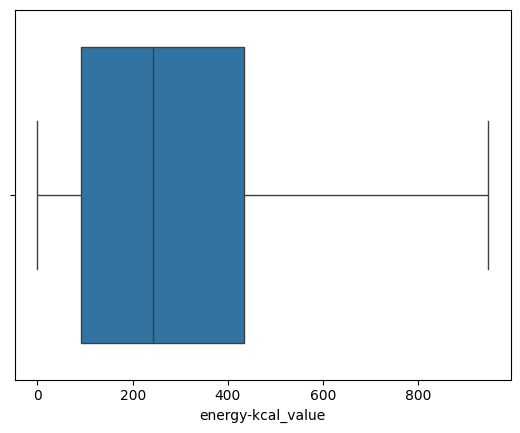

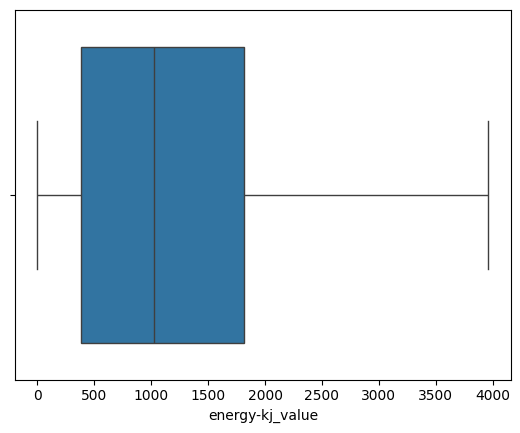

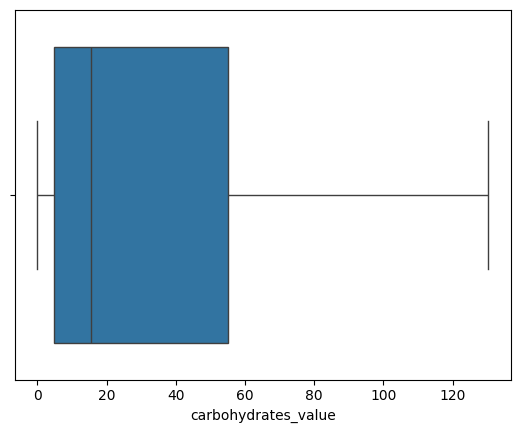

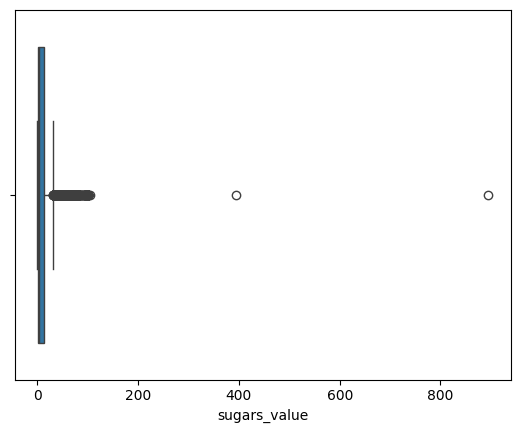

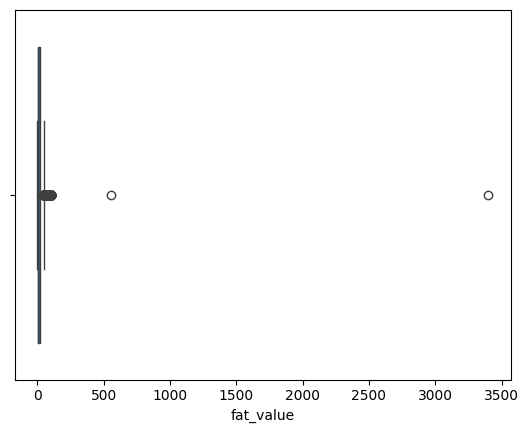

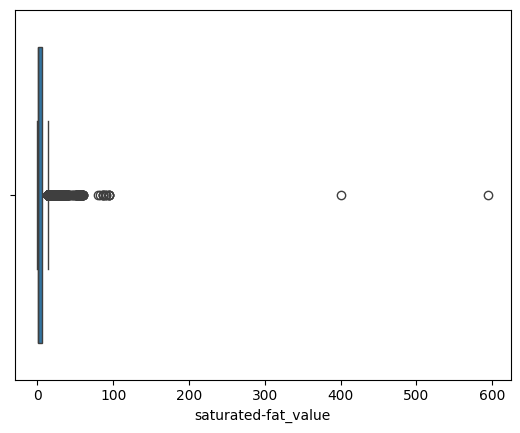

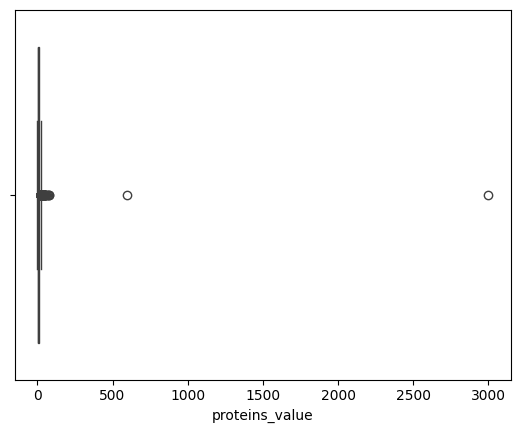

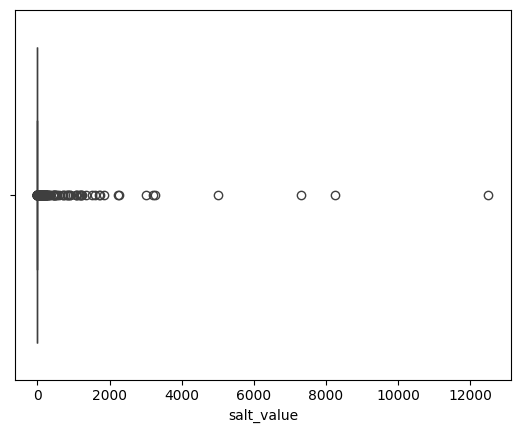

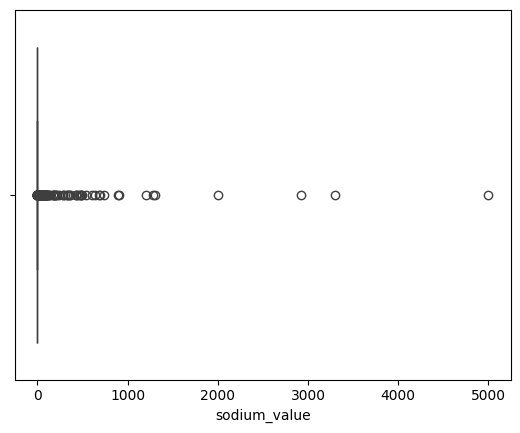

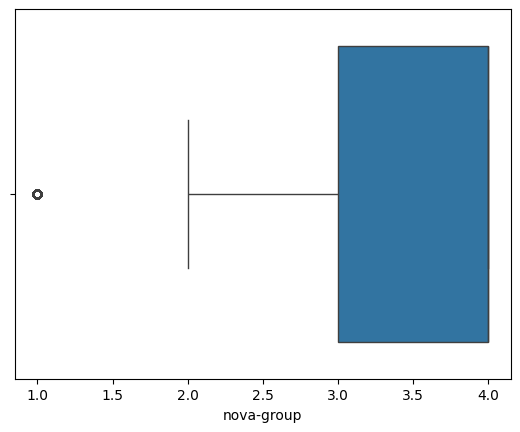

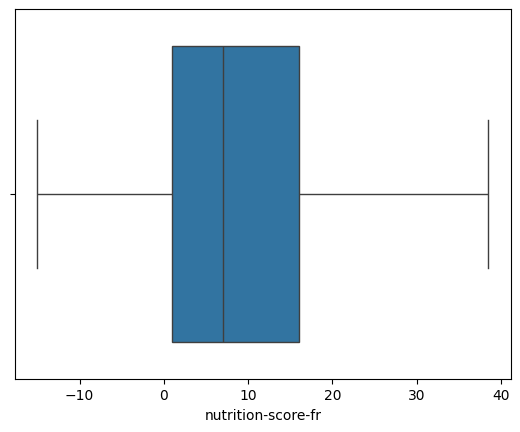

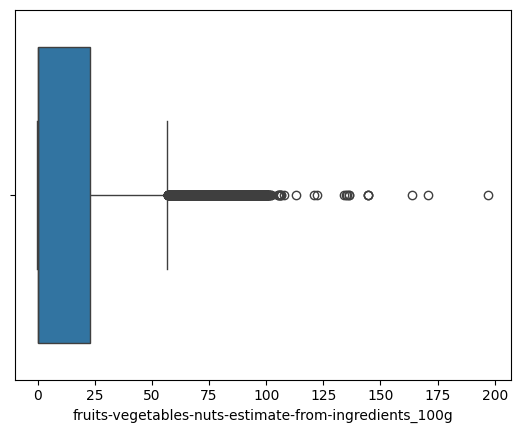

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

for i in nutrient_cols:

    sns.boxplot(x=df[i])
    plt.show()


In [ ]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]

# Example: find outliers in energy-kcal_value
for i in nutrient_cols:
    outliers = detect_outliers_iqr(df,i)
    print(f"printing {i} outliers")
    print(outliers)
    

printing energy-kcal_value outliers
             brands           code        product_name  energy-kcal_value  \
221       sunny via  3088543506255        sirop dagave        1600.000000   
2688   gastro mixte  6111259090132  pizzarella premium        5280.000000   
5349      hacendado  8480000054647    semillas de chia       45793.499044   
11915         jiffy    72486002205     corn muffin mix         990.000000   

       energy-kj_value  carbohydrates_value  sugars_value  fat_value  \
221            6694.40                402.5         395.0        2.5   
2688              1.00                 63.0           0.0       40.0   
5349           1916.00               3260.0          40.0     3400.0   
11915          4142.16                168.0          45.0       30.0   

       saturated-fat_value  proteins_value  salt_value  sodium_value  \
221                    0.0             2.5       0.000          0.00   
2688                  52.0             8.0      20.000          8.00   
5

In [104]:
outliers = detect_outliers_iqr(df,'energy-kj_value')
outliers

,brands,code,product_name,energy-kcal_value,energy-kj_value,carbohydrates_value,sugars_value,fat_value,saturated-fat_value,proteins_value,salt_value,sodium_value,nova-group,nutrition-score-fr,fruits-vegetables-nuts-estimate-from-ingredients_100g
221,sunny via,3088543506255,sirop dagave,1600.0,6694.40,402.5,395.0,2.5,0.0,2.5,0.000,0.00,1.0,20.0,0.0
11915,jiffy,72486002205,corn muffin mix,990.0,4142.16,168.0,45.0,30.0,12.0,12.0,5.175,2.07,4.0,7.0,0.0


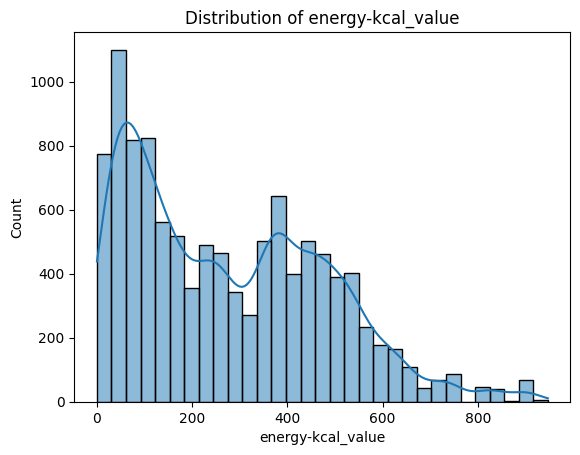

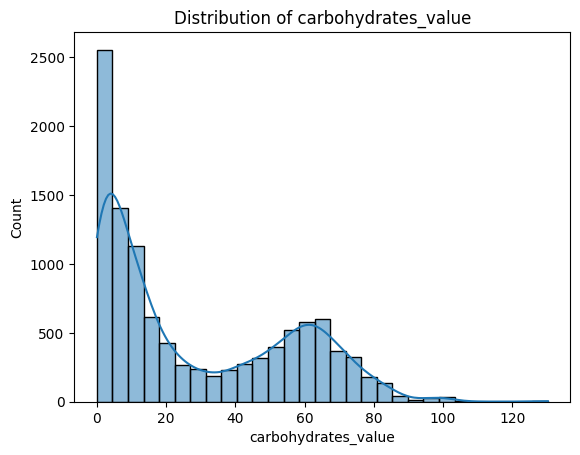

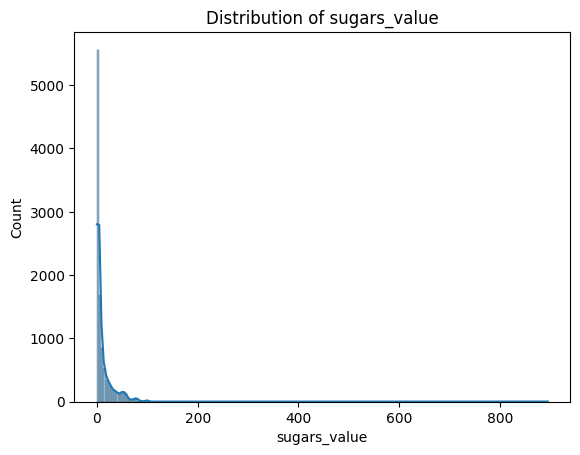

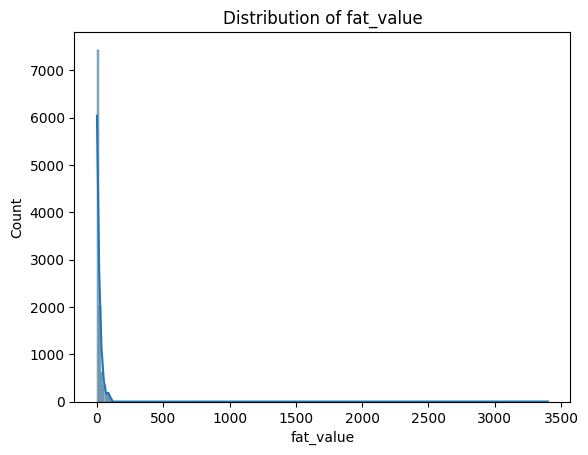

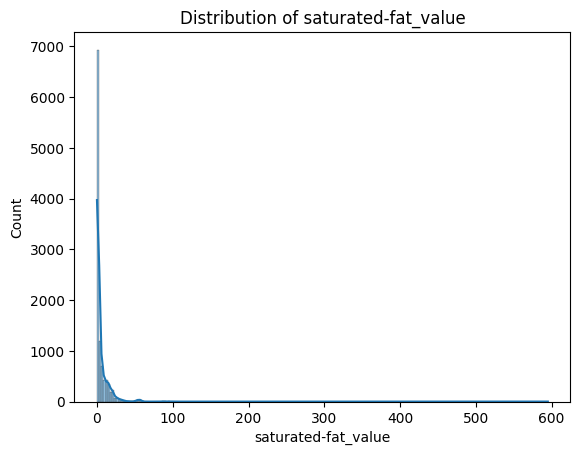

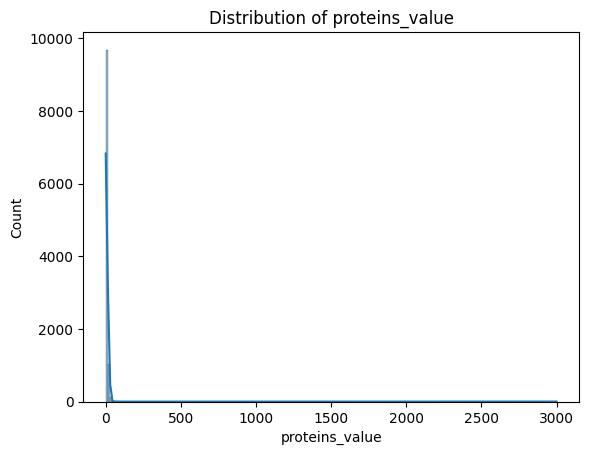

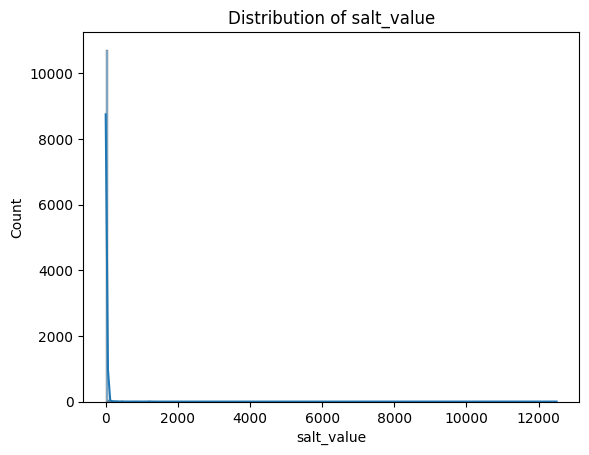

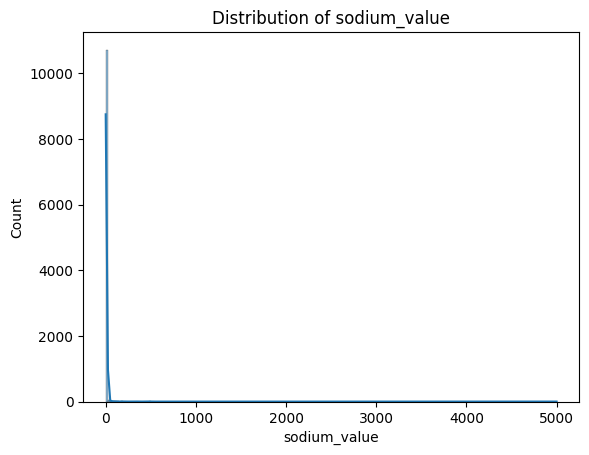

In [70]:
num_cols = ['energy-kcal_value', 'carbohydrates_value', 'sugars_value', 
            'fat_value', 'saturated-fat_value', 'proteins_value', 
            'salt_value', 'sodium_value']

for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


<Axes: xlabel='calorie_category', ylabel='count'>

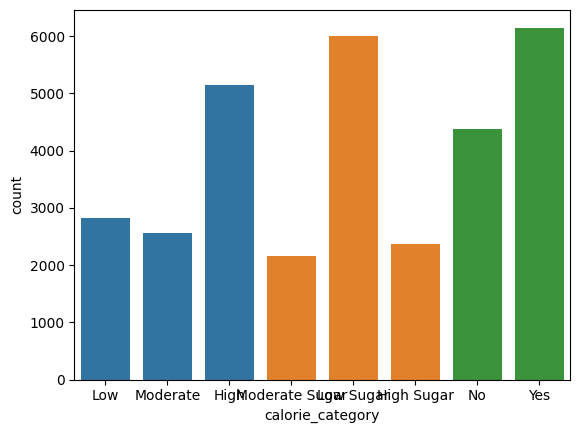

In [112]:
sns.countplot(x='calorie_category', data=df)
sns.countplot(x='sugar_category', data=df)
sns.countplot(x='is_ultra_processed', data=df)


<Axes: >

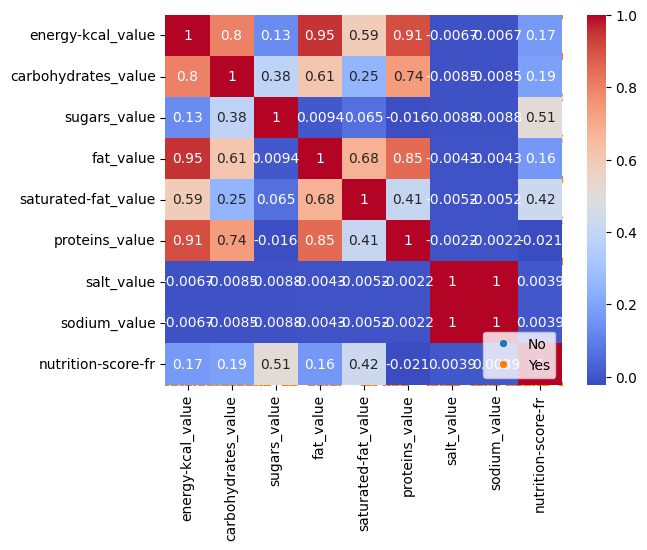

In [113]:
sns.scatterplot(x='sugars_value', y='energy-kcal_value', hue='is_ultra_processed', data=df)
sns.scatterplot(x='fat_value', y='nutrition-score-fr', data=df)
sns.heatmap(df[num_cols + ['nutrition-score-fr']].corr(), annot=True, cmap='coolwarm')


In [114]:
brand_nutrition = df.groupby('brands')[['sugars_value', 'fat_value', 'nutrition-score-fr']].mean().sort_values('nutrition-score-fr')
brand_nutrition

,sugars_value,fat_value,nutrition-score-fr
brands,,,
marque reperenotre jardinscamark filiale e leclerc,2.0,1.10,-15.0
sun,4.0,53.00,-10.0
happy bio,1.6,31.00,-10.0
bs,4.2,50.00,-10.0
the foodie market aldi,2.9,48.05,-10.0
...,...,...,...
mcvitie s,4.2,33.00,36.0
peperami,0.2,4.40,36.0
werthers original,53.2,16.10,36.0


<Axes: title={'center': 'Average Nutrient Levels by Processing Type'}, xlabel='is_ultra_processed'>

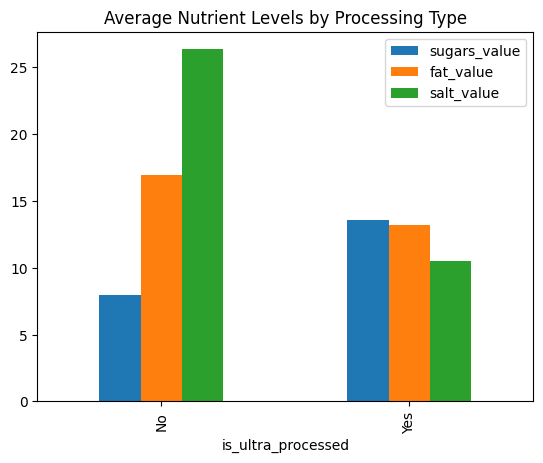

In [115]:
risk_df = df.groupby('is_ultra_processed')[['sugars_value', 'fat_value', 'salt_value']].mean()
risk_df.plot(kind='bar', title='Average Nutrient Levels by Processing Type')


In [94]:
df[(df['brands']=='heinz')&(df['product_name']=='tomato ketchup')]
#df[df['product_name'].str.contains("tomato ketchup", case=False, na=False)]


,brands,code,product_name,energy-kcal_value,energy-kj_value,carbohydrates_value,sugars_value,fat_value,saturated-fat_value,proteins_value,salt_value,sodium_value,nova-group,nutrition-score-fr,fruits-vegetables-nuts-estimate-from-ingredients_100g
126,heinz,50457236,tomato ketchup,15.0,62.760,3.5,3.4,0.0,0.1,0.2,0.148125,0.05925,3.0,9.0,62.168000
201,heinz,50457250,tomato ketchup,102.0,435.000,23.2,22.8,0.1,0.1,1.2,1.800000,0.72000,3.0,13.0,60.900000
213,heinz,87157215,tomato ketchup,102.0,435.000,23.2,22.8,0.1,0.1,1.2,1.800000,0.72000,3.0,13.0,61.800000
215,heinz,50457243,tomato ketchup,102.0,435.000,23.2,22.8,0.1,0.1,1.2,1.800000,0.72000,3.0,13.0,58.482143
570,heinz,8715700423913,tomato ketchup,64.0,271.000,12.0,11.0,0.1,0.0,1.4,0.900000,0.36000,4.0,6.0,53.125000
733,heinz,5000157079602,tomato ketchup,64.0,271.000,12.0,11.0,0.1,0.0,1.4,0.900000,0.36000,4.0,5.0,67.700000
1150,heinz,8715700421353,tomato ketchup,102.0,435.000,23.2,22.8,0.1,0.1,1.2,1.800000,0.72000,3.0,13.0,60.900000
2900,heinz,87157246,tomato ketchup,102.0,435.000,23.2,22.8,0.1,0.1,1.2,1.800000,0.72000,3.0,13.0,60.900000
5162,heinz,50157969,tomato ketchup,102.0,435.000,23.2,22.8,0.1,0.1,1.2,1.800000,0.72000,3.0,13.0,60.900000
6235,heinz,87157260,tomato ketchup,102.0,435.000,23.2,22.8,0.1,0.1,1.2,1.800000,0.72000,3.0,13.0,60.900000


In [70]:
df[df['product_name'].str.contains("tomato ketchup", case=False, na=False)].head(5)

,brands,code,product_name,energy-kcal_value,energy-kj_value,carbohydrates_value,sugars_value,fat_value,saturated-fat_value,proteins_value,fiber_value,salt_value,sodium_value,nova-group,nutrition-score-fr,fruits-vegetables-nuts-estimate-from-ingredients_100g
126,heinz,50457236,tomato ketchup,15.0,62.76,3.5,3.4,0.0,0.1,0.2,0.0,0.148125,0.05925,3.0,9.0,62.168000
201,heinz,50457250,tomato ketchup,102.0,435.00,23.2,22.8,0.1,0.1,1.2,0.0,1.800000,0.72000,3.0,13.0,60.900000
213,heinz,87157215,tomato ketchup,102.0,435.00,23.2,22.8,0.1,0.1,1.2,0.0,1.800000,0.72000,3.0,13.0,61.800000
215,heinz,50457243,tomato ketchup,102.0,435.00,23.2,22.8,0.1,0.1,1.2,0.0,1.800000,0.72000,3.0,13.0,58.482143
372,heinz,8715700407760,tomato ketchup bio,112.0,476.00,25.3,24.8,0.1,0.1,1.4,0.0,1.700000,0.68000,3.0,15.0,50.000000


In [69]:
# df[(df['brands']=='eau minerale naturelle')]
   #&(df['product_name']=='tomato ketchup')]
df[df['brands'].str.contains("eau minerale naturelle", case=False, na=False)]

,brands,code,product_name,energy-kcal_value,energy-kj_value,carbohydrates_value,sugars_value,fat_value,saturated-fat_value,proteins_value,fiber_value,salt_value,sodium_value,nova-group,nutrition-score-fr,fruits-vegetables-nuts-estimate-from-ingredients_100g
30,eau minerale naturelle des montagnes datlas,6111035001659,ain atlas,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0
34,eau minerale naturelle,6111035001635,ain atlas,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,120.0,48.0,NaN,0.0,0.0


In [60]:
# sf=df.groupby(["brands", "product_name"])["energy-kj_value"].mean().sort_values(ascending=False)
df.groupby(["brands", "product_name"])["energy-kj_value"].count()

brands                                                                                                                          product_name                 
03 x aldi 0925 05 x aldi 0925 07 x aldi 0925 09 x aldi 0925 11 x aldi 0925 12 x aldi 092501 x aldi 0825 milsani 01 x aldi 0925  haltbare fettarme milch          1
1540 vestby norwegen oluf lorentzen as toveien 22 mutti                                                                         cherrytomater 400 g              1
166 43122 parma  italy barilla barilla  barilla g e r fratelli  societa per azioni  via mantova 166 barilla                     pates spaghettoni ndeg7 500g     1
1664                                                                                                                            biere blonde sans alcool 1664    1
1664 blonde kronenbourg                                                                                                         1664                             1
                           

In [28]:
df.groupby(['brands','product_name'])['code'].count().sort_values(ascending=False)

brands          product_name                       
heinz           tomatoketchup                          15
cocacola        cocacola                               11
ferreronutella  nutella                                 9
                                                        7
ferrero         nutella                                 7
                                                       ..
yumyum          vegetableflavour                        1
                yumyumbeef                              1
yutaka          japanesebreadcrumbspankosemmelbrsel     1
                koreankimchi                            1
                3                                       1
Name: code, Length: 10536, dtype: int64

In [26]:
df['brands']=df['brands'].str.replace(' ','')
df['product_name']=df['product_name'].str.replace(' ','')

In [74]:
df['fiber_value'].value_counts()

fiber_value
0.000000    2504
0.500000     439
1.000000     208
3.600000     205
3.000000     190
            ... 
0.810000       1
7.111111       1
3.571429       1
0.378000       1
1.050000       1
Name: count, Length: 438, dtype: int64

In [71]:
for i in df.columns:
    print(i)

brands
code
product_name
energy-kcal_value
energy-kj_value
carbohydrates_value
sugars_value
fat_value
saturated-fat_value
proteins_value
fiber_value
salt_value
sodium_value
nova-group
nutrition-score-fr
fruits-vegetables-nuts-estimate-from-ingredients_100g


In [104]:
df[df['brands']=='by sainsburys wholesome']

,brands,code,product_name,energy-kcal_value,energy-kj_value,carbohydrates_value,sugars_value,fat_value,saturated-fat_value,proteins_value,salt_value,sodium_value,nova-group,nutrition-score-fr,fruits-vegetables-nuts-estimate-from-ingredients_100g
11972,by sainsburys wholesome,475730,wholemeal bread flour,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,-4.0,0.0


In [100]:
df.groupby('brands')['code'].count().sort_values(ascending=False)

brands
hacendado     380
tesco         275
carrefour     148
sainsburys    104
nestle        103
             ... 
yeo             1
ybarra          1
yakult          1
yaconco         1
swizzels        1
Name: code, Length: 3284, dtype: int64

In [106]:
df[df['product_name'].str.contains("wholemeal bread flour", case=False, na=False)]

,brands,code,product_name,energy-kcal_value,energy-kj_value,carbohydrates_value,sugars_value,fat_value,saturated-fat_value,proteins_value,salt_value,sodium_value,nova-group,nutrition-score-fr,fruits-vegetables-nuts-estimate-from-ingredients_100g
5603,allinsons,5010067372533,very strong wholemeal bread flour,333.0,1405.0,66.7,1.1,2.5,0.5,13.0,0.03,0.012,1.0,-6.0,0.0
9959,belbake,20448554,strong wholemeal bread flour,344.0,1456.0,63.9,2.1,2.2,0.3,12.7,0.01,0.004,1.0,-6.0,0.0
11972,by sainsburys wholesome,475730,wholemeal bread flour,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,-4.0,0.0


In [107]:
df.isnull().sum()

brands                                                      0
code                                                        0
product_name                                                0
energy-kcal_value                                         109
energy-kj_value                                           109
carbohydrates_value                                       119
sugars_value                                              171
fat_value                                                 114
saturated-fat_value                                       185
proteins_value                                            117
salt_value                                                701
sodium_value                                              701
nova-group                                                852
nutrition-score-fr                                       1264
fruits-vegetables-nuts-estimate-from-ingredients_100g     345
dtype: int64

In [108]:
df.dtypes

brands                                                    object
code                                                       int64
product_name                                              object
energy-kcal_value                                        float64
energy-kj_value                                          float64
carbohydrates_value                                      float64
sugars_value                                             float64
fat_value                                                float64
saturated-fat_value                                      float64
proteins_value                                           float64
salt_value                                               float64
sodium_value                                             float64
nova-group                                               float64
nutrition-score-fr                                       float64
fruits-vegetables-nuts-estimate-from-ingredients_100g    float64
dtype: object

In [112]:
df.isna().sum()

brands                                                      0
code                                                        0
product_name                                                0
energy-kcal_value                                         109
energy-kj_value                                           109
carbohydrates_value                                       119
sugars_value                                              171
fat_value                                                 114
saturated-fat_value                                       185
proteins_value                                            117
salt_value                                                638
sodium_value                                              638
nova-group                                                762
nutrition-score-fr                                       1169
fruits-vegetables-nuts-estimate-from-ingredients_100g     296
dtype: int64

In [110]:
df[df['product_name'] == "nan"]

,brands,code,product_name,energy-kcal_value,energy-kj_value,carbohydrates_value,sugars_value,fat_value,saturated-fat_value,proteins_value,salt_value,sodium_value,nova-group,nutrition-score-fr,fruits-vegetables-nuts-estimate-from-ingredients_100g
14,jaouda,6111242100985,nan,101.0,422.584,4.2,0.0,6.0,0.0,7.60,0.000,0.000,1.0,-2.0,0.000000
16,lilia,6111099003897,nan,675.0,2824.200,0.2,0.0,75.0,34.0,0.10,0.500,0.200,NaN,18.0,0.000000
38,ain saiss,6111128000460,nan,267.0,1092.024,17.0,5.5,6.1,1.8,5.15,0.020,0.008,1.0,0.0,0.000000
43,alesto,20005733,nan,712.0,2979.008,3.7,0.9,69.1,2.0,15.50,0.010,0.004,1.0,-6.0,100.000000
58,maruja,8425197712024,nan,539.0,2255.176,53.0,50.0,33.0,25.0,7.20,0.275,0.110,4.0,31.0,2.678571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11820,sante,5900617002266,nan,388.0,1638.000,67.0,12.0,5.6,0.8,12.00,0.250,0.100,4.0,-1.0,18.250000
11821,gullon,8410376052633,nan,454.0,1899.536,63.0,0.5,24.0,6.0,5.90,0.580,0.232,4.0,11.0,0.000000
11923,marks spencer,168069,nan,114.0,476.976,22.1,1.7,0.7,0.1,3.30,0.680,0.272,4.0,3.0,23.750000
11980,lune de miel,3088541015209,nan,320.0,1338.880,80.0,62.0,0.0,0.5,0.00,NaN,NaN,2.0,NaN,0.000000


In [111]:
df = df[df['product_name'] != "nan"]


In [115]:
df.dropna(subset=['nova-group'])

,brands,code,product_name,energy-kcal_value,energy-kj_value,carbohydrates_value,sugars_value,fat_value,saturated-fat_value,proteins_value,salt_value,sodium_value,nova-group,nutrition-score-fr,fruits-vegetables-nuts-estimate-from-ingredients_100g
1,jaouda,6111242100992,perly,97.0,406.000,9.4,7.5,3.0,1.15,8.0,NaN,NaN,3.0,NaN,0.000000
3,les eaux minerales doulmessidi ali,6111035000058,eau minerale naturelle,0.0,0.000,0.0,0.0,0.0,0.00,0.0,65.000,26.000,1.0,0.0,0.000000
5,jaouda,6111266962187,lait,45.0,188.000,4.9,0.0,1.5,1.00,3.1,0.225,0.090,3.0,-3.0,0.000000
6,cristaline,3274080005003,eau de source,0.0,0.000,0.0,0.0,0.0,0.00,0.0,52.500,21.000,1.0,0.0,0.000000
7,milky food professional,6111246721261,fromage blanc nature,80.6,337.000,6.1,0.0,12.0,0.00,7.3,0.000,0.000,3.0,-2.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11986,copella,5012876336096,cloudy apple juice,46.0,192.464,11.0,10.0,0.0,NaN,0.2,NaN,NaN,1.0,NaN,75.000000
11988,organic mamia,4088600042411,carrot cake soft oaty bars,383.0,1611.000,57.7,29.3,11.7,1.20,7.9,0.050,0.020,3.0,4.0,34.250000
11992,nairns,612322001612,nairns dark chocolate chip oat biscuits,454.0,1902.000,63.8,19.0,16.9,7.70,8.1,0.780,0.312,4.0,16.0,0.000000
11993,swizzels,5010478014510,drumstick squashies,356.0,1489.504,84.0,63.0,0.2,0.00,3.4,0.070,0.028,4.0,19.0,0.351562


In [116]:
10285/11997

0.8572976577477702

In [118]:
df=df.fillna(0)

In [119]:
df.isnull().sum()

brands                                                   0
code                                                     0
product_name                                             0
energy-kcal_value                                        0
energy-kj_value                                          0
carbohydrates_value                                      0
sugars_value                                             0
fat_value                                                0
saturated-fat_value                                      0
proteins_value                                           0
salt_value                                               0
sodium_value                                             0
nova-group                                               0
nutrition-score-fr                                       0
fruits-vegetables-nuts-estimate-from-ingredients_100g    0
dtype: int64